# Predicting Restaurant Food-Safety Risk Using Inspection History and Local Rodent Activity
## A Big Data Analytics Study of New York City

**Main Inquiry:** Can historical restaurant inspection records and local rodent
activity help explain and predict future restaurant food-safety risk in NYC?

**Q1 (Statistical Inference):** Which restaurant characteristics significantly
influence the probability of a poor inspection outcome?

**Q2 (Machine Learning):** Can ML models predict whether a restaurant will receive
a poor outcome at its next inspection?

## Section 1 - Import Libraries

In [56]:
# Import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
from sklearn.metrics import ConfusionMatrixDisplay

pd.set_option('display.max_columns', 50)   # so wide tables show fully

## 1.1 - Load the Restaurant Dataset 

In [57]:
# Load the restaurant dataset 

restaurant = pd.read_csv("Restaurant_data.csv", low_memory=False)
print(restaurant.shape)

(296772, 27)


In [58]:
restaurant.head()

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,VIOLATION CODE,VIOLATION DESCRIPTION,CRITICAL FLAG,SCORE,GRADE,GRADE DATE,RECORD DATE,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,50180289,BAGEL MARKET,Manhattan,168,WILLIAM STREET,10038.0,2126816303,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,06/01/2026,NaN,40.710345,-74.005631,101.0,1.0,1501.0,1001284.0,1.000930e+09,MN25,POINT (-74.005630559581 40.710345358667)
1,50092831,COLLECTIVE RETREATS,Manhattan,825,GRESHAM ROAD,NaN,3369090070,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,06/01/2026,NaN,0.000000,0.000000,NaN,NaN,NaN,1086338.0,1.000010e+09,NaN,NaN
2,50177630,SUNNYSIDE UP CAFE,Queens,45-16,QUEENS BOULEVARD,11104.0,9172169118,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,06/01/2026,NaN,40.743221,-73.919386,402.0,26.0,18300.0,4001953.0,4.001640e+09,QN31,POINT (-73.919386443535 40.743221431648)
3,50174895,CRAVIN CRISPY,Manhattan,195,CANAL STREET,10013.0,6462492959,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,06/01/2026,NaN,40.716982,-73.998247,102.0,1.0,4100.0,1002647.0,1.002050e+09,MN24,POINT (-73.998246812622 40.716982334635)
4,50187046,TEA ART CORP,Manhattan,147,SULLIVAN STREET,10012.0,9294012130,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,06/01/2026,NaN,40.727036,-74.001883,102.0,3.0,4900.0,1008044.0,1.005170e+09,MN24,POINT (-74.001883338303 40.727036414585)


In [59]:
restaurant.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296772 entries, 0 to 296771
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  296772 non-null  int64  
 1   DBA                    296770 non-null  object 
 2   BORO                   296772 non-null  object 
 3   BUILDING               295792 non-null  object 
 4   STREET                 296751 non-null  object 
 5   ZIPCODE                293663 non-null  float64
 6   PHONE                  296682 non-null  object 
 7   CUISINE DESCRIPTION    293275 non-null  object 
 8   INSPECTION DATE        296772 non-null  object 
 9   ACTION                 293367 non-null  object 
 10  VIOLATION CODE         290896 non-null  object 
 11  VIOLATION DESCRIPTION  290896 non-null  object 
 12  CRITICAL FLAG          296772 non-null  object 
 13  SCORE                  279734 non-null  float64
 14  GRADE                  146418 non-nu

## 1.2 - Shrink and load the rodent dataset

In [60]:
# Peek at the structure as the dataset is huge

rodent_peek = pd.read_csv("Rodent_Inspection.csv", nrows=5, low_memory=False)
print(rodent_peek.columns.tolist())
rodent_peek.head()

['INSPECTION_TYPE', 'JOB_TICKET_OR_WORK_ORDER_ID', 'JOB_ID', 'JOB_PROGRESS', 'BBL', 'BORO_CODE', 'BLOCK', 'LOT', 'HOUSE_NUMBER', 'STREET_NAME', 'ZIP_CODE', 'X_COORD', 'Y_COORD', 'LATITUDE', 'LONGITUDE', 'BOROUGH', 'INSPECTION_DATE', 'RESULT', 'APPROVED_DATE', 'LOCATION', 'COMMUNITY BOARD', 'COUNCIL DISTRICT', 'CENSUS TRACT', 'BIN', 'NTA']


,INSPECTION_TYPE,JOB_TICKET_OR_WORK_ORDER_ID,JOB_ID,JOB_PROGRESS,BBL,BORO_CODE,BLOCK,LOT,HOUSE_NUMBER,STREET_NAME,ZIP_CODE,X_COORD,Y_COORD,LATITUDE,LONGITUDE,BOROUGH,INSPECTION_DATE,RESULT,APPROVED_DATE,LOCATION,COMMUNITY BOARD,COUNCIL DISTRICT,CENSUS TRACT,BIN,NTA
0,Initial,11670593,PC6530234,1,2.032890e+09,2,3289,25,326.0,EAST 198 STREET,10458,1015316,255377,40.867727,-73.887461,Bronx,08/30/2010 03:23:11 PM,Passed,09/03/2010 10:43:36 AM,"(40.867726534028, -73.887461100839)",7.0,15.0,40502.0,2016678.0,Bedford Park
1,Initial,11758853,PC6101553,1,1.013290e+09,1,1329,121,245.0,EAST 55 STREET,10022,993525,215573,40.758511,-73.967434,Manhattan,08/18/2011 12:05:54 PM,Passed,08/19/2011 12:02:56 PM,"(40.758511490599, -73.967433834067)",6.0,4.0,10801.0,1038588.0,East Midtown-Turtle Bay
2,Initial,12504178,PC7270050,1,NaN,3,3141,20,NaN,MONTIETH STREET,11206,1002160,194840,40.701451,-73.935407,Brooklyn,10/10/2018 12:57:02 PM,Passed,10/11/2018 08:59:21 AM,"(40.7014506131434, -73.9354065814951)",NaN,NaN,NaN,NaN,NaN
3,Initial,12560587,PC6481130,1,1.021110e+09,1,2111,15,470.0,WEST 165 STREET,10032,1001506,244337,40.837644,-73.937771,Manhattan,02/07/2019 12:48:34 PM,Passed,02/13/2019 10:28:33 AM,"(40.83764407994, -73.93777140242)",12.0,10.0,24301.0,1062635.0,Washington Heights (South)
4,Initial,12628612,PC7229376,1,3.033350e+09,3,3335,26,308.0,LINDEN STREET,11237,1008035,193720,40.698368,-73.914504,Brooklyn,06/20/2019 04:02:23 PM,Passed,06/26/2019 01:35:17 PM,"(40.698368377396, -73.914503763762)",4.0,37.0,433.0,3076324.0,Bushwick (East)


In [61]:
# Aggregate the rodent file

# Read only the columns we need from the big rodent file

cols = ["INSPECTION_TYPE", "RESULT", "BOROUGH", "ZIP_CODE", "INSPECTION_DATE"]
rodent = pd.read_csv("Rodent_Inspection.csv", usecols=cols, low_memory=False)
print("Raw rodent shape:", rodent.shape)

# minimal cleaning
rodent["INSPECTION_DATE"] = pd.to_datetime(rodent["INSPECTION_DATE"], errors="coerce")
rodent = rodent.dropna(subset=["INSPECTION_DATE", "ZIP_CODE"])

# Clean ZIP to a 5-digit string (so it merges cleanly with restaurant ZIPCODE later)

rodent["zip"] = rodent["ZIP_CODE"].astype(float).astype(int).astype(str).str.zfill(5)

# Month bucket for later merging with inspections

rodent["year_month"] = rodent["INSPECTION_DATE"].dt.to_period("M").astype(str)

# Flag ACTIVE rodent presence: catches BOTH "Rat Activity" and
# "Failed for Rat Activity and Other Reason". na=False keeps it safe on any blanks

rodent["rat_activity"] = rodent["RESULT"].str.contains("Rat Activity", na=False).astype(int)

# Quick sanity check that the flag worked (there should not be any zeroes)

print("Rows flagged as rat activity:", rodent["rat_activity"].sum())

Raw rodent shape: (3049477, 5)


/var/folders/56/tp_8h8d9701d2thp5yc91l_80000gn/T/ipykernel_39533/124462035.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rodent["INSPECTION_DATE"] = pd.to_datetime(rodent["INSPECTION_DATE"], errors="coerce")


Rows flagged as rat activity: 510184


In [62]:
# Aggregate to ZIP + month

rodent_monthly = (
    rodent.groupby(["zip", "year_month"])
    .agg(rodent_inspections=("RESULT", "size"),
         rodent_activity_count=("rat_activity", "sum"))
    .reset_index()
)

# Save the small file (this file will be used throughout the analysis)

rodent_monthly.to_csv("rodent_monthly_by_zip.csv", index=False)

print("Aggregated shape:", rodent_monthly.shape)
print(rodent_monthly.head(10))

Aggregated shape: (33664, 4)
     zip year_month  rodent_inspections  rodent_activity_count
0  00000    2010-08                   1                      0
1  00000    2010-09                   2                      1
2  00000    2010-10                   6                      1
3  00000    2010-11                   6                      0
4  00000    2010-12                   2                      0
5  00000    2011-03                   2                      0
6  00000    2011-04                   1                      0
7  00000    2011-05                   1                      0
8  00000    2011-06                   3                      0
9  00000    2011-07                   1                      0


In [63]:
# Check how many rows have the invalid 00000 ZIP

print("Rows with 00000 zip:", (rodent_monthly["zip"] == "00000").sum())

# Drop them — 00000 is not a real ZIP code

rodent_monthly = rodent_monthly[rodent_monthly["zip"] != "00000"]

# Re-save the cleaned version

rodent_monthly.to_csv("rodent_monthly_by_zip.csv", index=False)

print("Shape after dropping 00000:", rodent_monthly.shape)
print("ZIP range check — sample of unique zips:")
print(sorted(rodent_monthly["zip"].unique())[:10])

Rows with 00000 zip: 163
Shape after dropping 00000: (33501, 4)
ZIP range check — sample of unique zips:
['00458', '01045', '10000', '10001', '10002', '10003', '10004', '10005', '10006', '10007']


# Section 2.0 - Raw Data Audit 

Before cleaning, the raw restaurant data was inspected for missing values and duplicates, date range, and the distribution of key variables. 

Note: The rodent audit was performed during aggregation above. 

In [64]:
# Define a reusable helper function to summarise the distinct values of a column
# and their frequencies

def get_distinct_counts(data, column):
    distinct_values = (
        data[column]
        .value_counts(dropna=False)
        .reset_index()
    )
    distinct_values.columns = [column, "count"]
    return distinct_values

In [65]:
# Quantify missing values in each column to identify variables that may require
# cleaning or exclusion. GRADE in particular is expected to be substantially
# incomplete, which informs the decision to derive the target variable from SCORE

na_counts = restaurant.isna().sum()
print(na_counts)

CAMIS                         0
DBA                           2
BORO                          0
BUILDING                    980
STREET                       21
ZIPCODE                    3109
PHONE                        90
CUISINE DESCRIPTION        3497
INSPECTION DATE               0
ACTION                     3405
VIOLATION CODE             5876
VIOLATION DESCRIPTION      5876
CRITICAL FLAG                 0
SCORE                     17038
GRADE                    150354
GRADE DATE               160485
RECORD DATE                   0
INSPECTION TYPE            3405
Latitude                   1666
Longitude                  1666
Community Board            4728
Council District           4738
Census Tract               4738
BIN                        5971
BBL                        1666
NTA                        4728
Location                   4728
dtype: int64


In [66]:
# Identify fully duplicated rows. Exact duplicates would bias frequency counts and any subsequent aggregation, so their presence is assessed before cleaning

duplicates = restaurant.duplicated()
print("Number of fully duplicated rows:", duplicates.sum())

Number of fully duplicated rows: 121


In [67]:
# Examine the distribution of boroughs
# (e.g. a placeholder value of "0") that must be removed during cleaning

get_distinct_counts(restaurant, "BORO")

,BORO,count
0,Manhattan,109943
1,Brooklyn,75462
2,Queens,73946
3,Bronx,27277
4,Staten Island,9781
5,0,363


In [68]:
# Examine the distribution of letter grades
# confirms that GRADE is unsuitable as the primary target variable

get_distinct_counts(restaurant, "GRADE")

,GRADE,count
0,NaN,150354
1,A,99115
2,B,18435
3,C,13473
4,N,10137
5,Z,4405
6,P,853


In [69]:
# Examine the critical-flag categories. This variable indicates whether a recorded violation is critical to food safety and will be used to engineer violation features

get_distinct_counts(restaurant, "CRITICAL FLAG")

,CRITICAL FLAG,count
0,Critical,156025
1,Not Critical,132989
2,Not Applicable,7758


In [70]:
# Examine the most frequent cuisine types

get_distinct_counts(restaurant, "CUISINE DESCRIPTION").head(15)

,CUISINE DESCRIPTION,count
0,American,44594
1,Chinese,29366
2,Coffee/Tea,21416
3,Pizza,17171
4,Latin American,14867
5,Mexican,12106
6,Bakery Products/Desserts,11602
7,Caribbean,11086
8,Japanese,10424
9,Italian,9601


In [71]:
# Convert SCORE to numeric and summarise its distribution. SCORE is the basis for the
# target variable. So confirming its range and central tendency is essential

restaurant["SCORE"] = pd.to_numeric(restaurant["SCORE"], errors="coerce")
print(restaurant["SCORE"].describe())

# Convert INSPECTION DATE to datetime and quantify placeholder dates. The dataset uses
# 01/01/1900 to denote establishments without a genuine inspection

restaurant["INSPECTION DATE"] = pd.to_datetime(restaurant["INSPECTION DATE"], errors="coerce")
placeholder = (restaurant["INSPECTION DATE"] == pd.Timestamp("1900-01-01")).sum()
print("\nNumber of placeholder (01/01/1900) records:", placeholder)
print("Inspection date range:", restaurant["INSPECTION DATE"].min(),
      "to", restaurant["INSPECTION DATE"].max())

count    279734.000000
mean         25.426187
std          19.032574
min           0.000000
25%          12.000000
50%          21.000000
75%          33.000000
max         214.000000
Name: SCORE, dtype: float64

Number of placeholder (01/01/1900) records: 3405
Inspection date range: 1900-01-01 00:00:00 to 2026-05-30 00:00:00


# Section 3.0 - Restaurant Inspection Data Cleaning 

The raw data is cleaned to produce a realiable dataset for analysis.

## 3.1 Select Relevant Columns

In [72]:
# Retain only the columns relevant to the three questions. Identifiers such as
# phone number, building, street, and BIN/BBL are excluded as they do not contribute to
# explaining or predicting inspection outcomes

keep_cols = [
    "CAMIS", "DBA", "BORO", "ZIPCODE", "CUISINE DESCRIPTION",
    "INSPECTION DATE", "INSPECTION TYPE", "ACTION",
    "VIOLATION CODE", "VIOLATION DESCRIPTION", "CRITICAL FLAG",
    "SCORE", "GRADE", "Latitude", "Longitude"
]
restaurant = restaurant[keep_cols]
print("Shape after column selection:", restaurant.shape)

Shape after column selection: (296772, 15)


## 3.2 Clean Dates

In [73]:
# Remove placeholder (01/01/1900) and missing inspection dates. These are not
# genuine inspection dates and would distort the analysis

restaurant = restaurant[restaurant["INSPECTION DATE"] != pd.Timestamp("1900-01-01")]
restaurant = restaurant.dropna(subset=["INSPECTION DATE"])

print("Rows after date cleaning:", restaurant.shape[0])
print("Cleaned inspection date range:",
      restaurant["INSPECTION DATE"].min().date(), "to",
      restaurant["INSPECTION DATE"].max().date())

Rows after date cleaning: 293367
Cleaned inspection date range: 2007-08-10 to 2026-05-30


## 3.3 Clean Location Variables 

In [74]:
# Remove invalid borough entries (recorded as "0")

restaurant = restaurant[restaurant["BORO"] != "0"]

# Standardise ZIP code as a five-digit string after removing missing values. 
# Consistent Zip format is required for the merge with the rodent data

restaurant = restaurant.dropna(subset=["ZIPCODE"])
restaurant["ZIPCODE"] = (
    restaurant["ZIPCODE"].astype(float).astype(int).astype(str).str.zfill(5)
)

print("Rows after location cleaning:", restaurant.shape[0])
print("Distinct boroughs:", restaurant["BORO"].unique().tolist())

Rows after location cleaning: 290072
Distinct boroughs: ['Queens', 'Manhattan', 'Bronx', 'Brooklyn', 'Staten Island']


## 3.4 Derive Violation Indicators 


In [75]:
# Confirm SCORE is numeric and quantify any remaining missing values

restaurant["SCORE"] = pd.to_numeric(restaurant["SCORE"], errors="coerce")
print("Missing SCORE values:", restaurant["SCORE"].isna().sum())

# Derive an indicator for whether each row records a critical violation.

restaurant["is_critical"] = (restaurant["CRITICAL FLAG"] == "Critical").astype(int)

# Derive an indicator for whether each row records an actual violation, used to
# count total violations per inspection

restaurant["has_violation"] = restaurant["VIOLATION CODE"].notna().astype(int)

Missing SCORE values: 13504


## 3.5 Group Rare Cuisines

In [76]:
# Group infrequent cuisine types into an "Other" category

cuisine_counts = restaurant["CUISINE DESCRIPTION"].value_counts()
top_cuisines = cuisine_counts[cuisine_counts >= 2000].index

restaurant["CUISINE_CLEAN"] = np.where(
    restaurant["CUISINE DESCRIPTION"].isin(top_cuisines),
    restaurant["CUISINE DESCRIPTION"],
    "Other"
)

print("Distinct cuisines before grouping:", restaurant["CUISINE DESCRIPTION"].nunique())
print("Distinct cuisines after grouping:", restaurant["CUISINE_CLEAN"].nunique())

Distinct cuisines before grouping: 90
Distinct cuisines after grouping: 30


# Section 4.0 - Convert Restaurant Data to Inspection Level

THe raw data is structured at the violation level, meaning a single inspection records multiple violations appears as multiple rows.

For this analysis, the unit of interest is the inspection event, so the data is aggregated to one row per restaurant per inspection date. 

Without this step, inspections with many violations would be over-represented and potentially bias the results 

## 4.1 Confirm the Duplications

In [77]:
# Quantify the extent of violation-level duplication by comparing the number of raw
# rows to the number of unique inspection events
# This will confirm the need for aggregation

n_rows = restaurant.shape[0]
n_events = restaurant.groupby(["CAMIS", "INSPECTION DATE"]).ngroups
print("Violation-level rows:", n_rows)
print("Unique inspection events:", n_events)
print("Average rows per inspection:", round(n_rows / n_events, 2))

Violation-level rows: 290072
Unique inspection events: 83655
Average rows per inspection: 3.47


## 4.2 Aggregate to inspection level 

In [78]:
# Aggregate the violation-level data to one row per inspection event

inspections = (
    restaurant
    .groupby(["CAMIS", "DBA", "BORO", "ZIPCODE", "CUISINE_CLEAN", "INSPECTION DATE"],
             dropna=False)
    .agg(
        score=("SCORE", "max"),
        violation_count=("has_violation", "sum"),
        critical_violation_count=("is_critical", "sum"),
        latitude=("Latitude", "first"),
        longitude=("Longitude", "first"),
    )
    .reset_index()
)

print("Inspection-level dataset shape:", inspections.shape)
inspections.head()

Inspection-level dataset shape: (83655, 11)


,CAMIS,DBA,BORO,ZIPCODE,CUISINE_CLEAN,INSPECTION DATE,score,violation_count,critical_violation_count,latitude,longitude
0,30075445,MORRIS PARK BAKE SHOP,Bronx,10462,Bakery Products/Desserts,2023-08-01,38.0,3,2,40.848231,-73.855972
1,30075445,MORRIS PARK BAKE SHOP,Bronx,10462,Bakery Products/Desserts,2023-08-22,12.0,3,1,40.848231,-73.855972
2,30075445,MORRIS PARK BAKE SHOP,Bronx,10462,Bakery Products/Desserts,2024-11-08,10.0,3,1,40.848231,-73.855972
3,30075445,MORRIS PARK BAKE SHOP,Bronx,10462,Bakery Products/Desserts,2026-02-27,7.0,2,1,40.848231,-73.855972
4,30191841,D.J. REYNOLDS,Manhattan,10019,Irish,2023-04-23,10.0,2,2,40.767326,-73.984310


# Section 5.0 - Define Food-Safety Risk Target Variable 

- A binary target varaible is defined to represent a poor inspection outcome

- NYC's grading thresholds assign a score of 0-13 (Grade A), 14-27 (Grade B), 28 or above (grade C)


## 5.1 Create the target

In [79]:
# Remove the samll number of inspections with no recorded score and then
# derive the binary target 
# Binary Target: 1 indicates a poor outcome (score above 13), and 0 indicates an A- grade outcome (score of 13 or below)

inspections = inspections.dropna(subset=["score"])
inspections["poor_outcome"] = (inspections["score"] > 13).astype(int)

inspections[["score", "poor_outcome"]].head(10)


,score,poor_outcome
0,38.0,1
1,12.0,0
2,10.0,0
3,7.0,0
4,10.0,0
5,24.0,1
6,10.0,0
7,0.0,0
8,10.0,0
9,9.0,0


## 5.2 Check The Distribution and Confirm the Median Shift 

In [80]:
# Assess the balance of the target variable. A base rate near 40% indicates the
# classes are reasonably balanced, allowing the models to be trained without resampling

print(get_distinct_counts(inspections, "poor_outcome"))
print("\nPoor outcome rate:", round(inspections["poor_outcome"].mean(), 3))

# Confirm the inspection-level score distribution. Note the median is 13 at the
# inspection level

print("\nInspection-level score summary:")
print(inspections["score"].describe())

   poor_outcome  count
0             0  49519
1             1  33082

Poor outcome rate: 0.401

Inspection-level score summary:
count    82601.000000
mean        17.841455
std         14.864295
min          0.000000
25%          9.000000
50%         13.000000
75%         24.000000
max        214.000000
Name: score, dtype: float64


# Section 6 - Prepare Rodent Data and Time Keys for Merging 

- The rodent inspection data was aggregated to ZIP code and month in section 1.2 

- It is reloaded and a matching year-month key is created on the two restaurant data so the two datasets can be merged on location and time. 

- Time-based features required for the analysis are also derived from the inspection date 

In [81]:
# reload the clean rodent file 

rodent_monthly = pd.read_csv("rodent_monthly_by_zip.csv", dtype={"zip": str})

print("Rodent monthly shape:", rodent_monthly.shape)
rodent_monthly.head()

Rodent monthly shape: (33501, 4)


,zip,year_month,rodent_inspections,rodent_activity_count
0,00458,2020-03,1,1
1,01045,2021-05,1,0
2,10000,2019-01,1,1
3,10000,2019-08,1,1
4,10000,2023-07,1,1


In [82]:
# create time key and time features on the restaurant side dataset 

inspections["year"] = inspections["INSPECTION DATE"].dt.year
inspections["month"] = inspections["INSPECTION DATE"].dt.month
inspections["year_month"] = inspections["INSPECTION DATE"].dt.to_period("M").astype(str)

# Map calendar months to meteorological seasons.
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

inspections["season"] = inspections["month"].apply(get_season)

inspections[["INSPECTION DATE", "year", "month", "year_month", "season"]]

,INSPECTION DATE,year,month,year_month,season
0,2023-08-01,2023,8,2023-08,Summer
1,2023-08-22,2023,8,2023-08,Summer
2,2024-11-08,2024,11,2024-11,Autumn
3,2026-02-27,2026,2,2026-02,Winter
4,2023-04-23,2023,4,2023-04,Spring
...,...,...,...,...,...
83650,2026-05-29,2026,5,2026-05,Spring
83651,2026-05-29,2026,5,2026-05,Spring
83652,2026-05-28,2026,5,2026-05,Spring
83653,2026-05-18,2026,5,2026-05,Spring


# Section 7 - Feature Engineering 

- Create variables representing historical risk using only information available before each inspection.

- Previous-inspection hiostory is built with groupby + shift: prior rodent activity is taken from the month before each inspection

## 7.1 Previous Inspection History

In [83]:
# Sort by restaurant and date so each restaurant's inspections are in time order 

inspections = inspections.sort_values(["CAMIS", "INSPECTION DATE"])

# shift(1) within each restaurant pulls the previous inspection's values forward

grp = inspections.groupby("CAMIS")
inspections["previous_score"] = grp["score"].shift(1)
inspections["previous_poor_outcome"] = grp["poor_outcome"].shift(1)
inspections["previous_violation_count"] = grp["violation_count"].shift(1)
inspections["previous_critical_violation_count"] = grp["critical_violation_count"].shift(1)
inspections["days_since_last_inspection"] = grp["INSPECTION DATE"].diff().dt.days

print(inspections[["CAMIS", "INSPECTION DATE", "score",
                   "previous_score", "days_since_last_inspection"]].head(8))

      CAMIS INSPECTION DATE  score  previous_score  days_since_last_inspection
0  30075445      2023-08-01   38.0             NaN                         NaN
1  30075445      2023-08-22   12.0            38.0                        21.0
2  30075445      2024-11-08   10.0            12.0                       444.0
3  30075445      2026-02-27    7.0            10.0                       476.0
4  30191841      2023-04-23   10.0             NaN                         NaN
5  30191841      2024-11-20   24.0            10.0                       577.0
6  30191841      2025-02-20   10.0            24.0                        92.0
7  40356018      2024-04-16    0.0             NaN                         NaN


## 7.2 Previous-month rodent activity (merge)

In [84]:
# Build the "previous month" key on each inspection
# Period arithmetic (minus 1 month) keeps this leakage-safe and uses a simple lambda

inspections["prev_month"] = (
    pd.PeriodIndex(inspections["year_month"], freq="M") - 1
).astype(str)

# Rename rodent columns so the merge is clear, then merge onto the previous month
rodent_prev = rodent_monthly.rename(columns={
    "year_month": "prev_month",
    "rodent_activity_count": "rodent_activity_prev_month",
    "rodent_inspections": "rodent_inspections_prev_month"
})

inspections = inspections.merge(
    rodent_prev[["zip", "prev_month",
                 "rodent_activity_prev_month", "rodent_inspections_prev_month"]],
    left_on=["ZIPCODE", "prev_month"],
    right_on=["zip", "prev_month"],
    how="left"
)

# Where there was no rodent inspection nearby, there is no recorded activity = 0

inspections["rodent_activity_prev_month"] = inspections["rodent_activity_prev_month"].fillna(0)
inspections["rodent_inspections_prev_month"] = inspections["rodent_inspections_prev_month"].fillna(0)

print(inspections[["ZIPCODE", "year_month", "prev_month",
                   "rodent_activity_prev_month"]].head())

  ZIPCODE year_month prev_month  rodent_activity_prev_month
0   10462    2023-08    2023-07                        20.0
1   10462    2023-08    2023-07                        20.0
2   10462    2024-11    2024-10                        13.0
3   10462    2026-02    2026-01                         8.0
4   10019    2023-04    2023-03                        17.0


In [85]:
# How many inspections matched a previous-month rodent record vs filled with 0

matched = (inspections["rodent_inspections_prev_month"] > 0).sum()
print("Inspections with prior-month rodent data:", matched)
print("Inspections with none (filled 0):", len(inspections) - matched)
print("Match rate:", round(matched / len(inspections), 3))

Inspections with prior-month rodent data: 80567
Inspections with none (filled 0): 2034
Match rate: 0.975


In [86]:
print("Rows now:", len(inspections))

Rows now: 82601


# Section 8 - Final Dataset Overview 

- Summarise the finished modelling dataset before analysis: its size, time coverage,
remaining missing values, the final list of variables, and the distribution of the
target. 
    
- This provides the basis for the Data Overview section of the report.

In [87]:
# Overall size and time coverage of the final dataset

print("Final dataset shape:", inspections.shape)
print("Date range:", inspections["INSPECTION DATE"].min().date(),
      "to", inspections["INSPECTION DATE"].max().date())
print("Number of restaurants:", inspections["CAMIS"].nunique())
print("Number of ZIP codes:", inspections["ZIPCODE"].nunique())
print("Number of cuisine types:", inspections["CUISINE_CLEAN"].nunique())

Final dataset shape: (82601, 25)
Date range: 2007-08-10 to 2026-05-30
Number of restaurants: 27323
Number of ZIP codes: 221
Number of cuisine types: 30


In [88]:
# check missing values remaining

print(inspections.isna().sum())

CAMIS                                    0
DBA                                      0
BORO                                     0
ZIPCODE                                  0
CUISINE_CLEAN                            0
INSPECTION DATE                          0
score                                    0
violation_count                          0
critical_violation_count                 0
latitude                               491
longitude                              491
poor_outcome                             0
year                                     0
month                                    0
year_month                               0
season                                   0
previous_score                       27323
previous_poor_outcome                27323
previous_violation_count             27323
previous_critical_violation_count    27323
days_since_last_inspection           27323
prev_month                               0
zip                                   2034
rodent_acti

In [89]:
# Distribution of the target variable in the final dataset 

print(get_distinct_counts(inspections, "poor_outcome"))
print("\nPoor outcome rate:", round(inspections["poor_outcome"].mean(), 3))

   poor_outcome  count
0             0  49519
1             1  33082

Poor outcome rate: 0.401


In [90]:
# Final list of variables for analysis 

print("Final variables:")
print(inspections.columns.tolist())

Final variables:
['CAMIS', 'DBA', 'BORO', 'ZIPCODE', 'CUISINE_CLEAN', 'INSPECTION DATE', 'score', 'violation_count', 'critical_violation_count', 'latitude', 'longitude', 'poor_outcome', 'year', 'month', 'year_month', 'season', 'previous_score', 'previous_poor_outcome', 'previous_violation_count', 'previous_critical_violation_count', 'days_since_last_inspection', 'prev_month', 'zip', 'rodent_activity_prev_month', 'rodent_inspections_prev_month']


In [91]:
# Drop the redundant rodent key column left over from the merge

inspections = inspections.drop(columns=["zip"])

# Keep only inspections that have prior history. 

model_data = inspections.dropna(subset=["previous_score"]).copy()

print("Rows before:", len(inspections))
print("Rows after keeping only inspections with history:", len(model_data))
print("Poor outcome rate (modelling data):", round(model_data["poor_outcome"].mean(), 3))

Rows before: 82601
Rows after keeping only inspections with history: 55278
Poor outcome rate (modelling data): 0.382


# Section 9 - Exploratory Data Analysis 

- This section explore the modelling dataset to understand the target varaible and the patternns that motivate Q1 and Q2. 

- Each chart is chosen to set up a specific part of the anlaysis rather than to explore at random 

## 9.1 Distribution of the Target Variable 

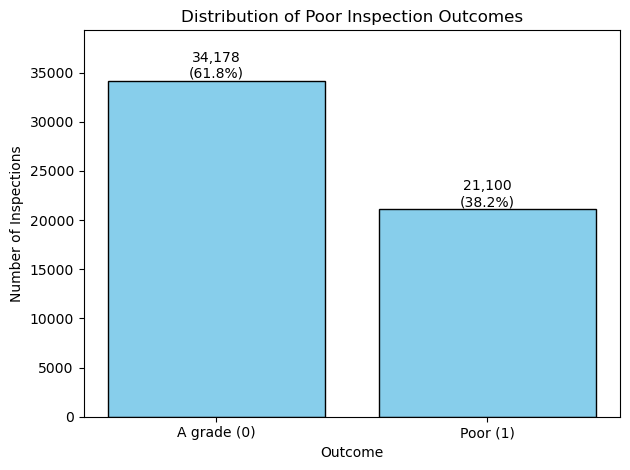

In [92]:
counts = model_data["poor_outcome"].value_counts().sort_index()
total = counts.sum()

bars = plt.bar(["A grade (0)", "Poor (1)"], counts.values,
               color="skyblue", edgecolor="black")

# Add count and percentage labels above each bar

for bar, count in zip(bars, counts.values):
    pct = count / total * 100
    plt.text(bar.get_x() + bar.get_width() / 2,      
             bar.get_height(),                        
             f"{count:,}\n({pct:.1f}%)",              
             ha="center", va="bottom")

plt.title("Distribution of Poor Inspection Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Inspections")
plt.ylim(0, counts.max() * 1.15)   
plt.tight_layout()
plt.savefig("target_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## 9.2 Previous Inspection Score by Current Outcome 

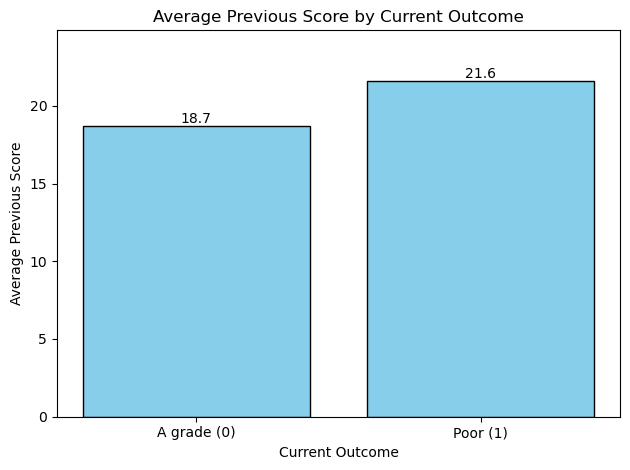

In [93]:
# if hisotry matters, poor outcomes should have a higher average previous score

prev_by_outcome = model_data.groupby("poor_outcome")["previous_score"].mean()

bars = plt.bar(["A grade (0)", "Poor (1)"], prev_by_outcome.values,
               color="skyblue", edgecolor="black")

# Add the exact average score above each bar

for bar, value in zip(bars, prev_by_outcome.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height(),
             f"{value:.1f}",                 # one decimal, e.g. 18.7
             ha="center", va="bottom")

plt.title("Average Previous Score by Current Outcome")
plt.xlabel("Current Outcome")
plt.ylabel("Average Previous Score")
plt.ylim(0, prev_by_outcome.max() * 1.15)    # headroom so labels aren't clipped
plt.tight_layout()
plt.savefig("prev_score_by_outcome.png", dpi=200, bbox_inches="tight")
plt.show()

## 9.3 Poor-outcome rate by cuisines type ( Top 10 cuisines by number of insepctions)

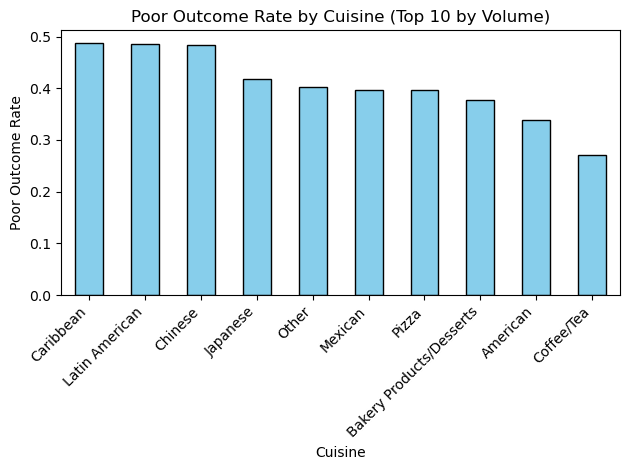

In [94]:
# Sorted descending so the highest-risk cuisines are highlighted 

top10 = model_data["CUISINE_CLEAN"].value_counts().head(10).index
rate_by_cuisine = (
    model_data[model_data["CUISINE_CLEAN"].isin(top10)]
    .groupby("CUISINE_CLEAN")["poor_outcome"].mean()
    .sort_values(ascending=False)
)

rate_by_cuisine.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Poor Outcome Rate by Cuisine (Top 10 by Volume)")
plt.xlabel("Cuisine")
plt.ylabel("Poor Outcome Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9.4 Poor-outcome Rate by Prior-month Rodent Activity band. 

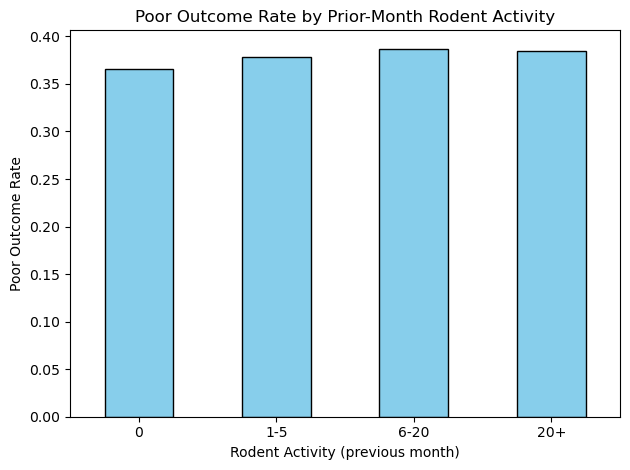

In [95]:
# banding the rodent count lets us see whether higher rodent acitivity is linked to a higher poor-outcome rate
model_data["rodent_band"] = pd.cut(
    model_data["rodent_activity_prev_month"],
    bins=[-1, 0, 5, 20, 100000],
    labels=["0", "1-5", "6-20", "20+"]
)
rate_by_rodent = model_data.groupby("rodent_band", observed=True)["poor_outcome"].mean()

rate_by_rodent.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Poor Outcome Rate by Prior-Month Rodent Activity")
plt.xlabel("Rodent Activity (previous month)")
plt.ylabel("Poor Outcome Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 9.5 Number of Inspections per Year

It is to show the dataset's time coverage

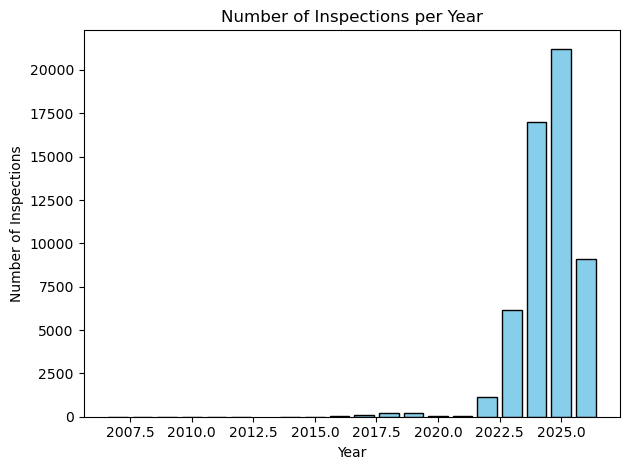

In [96]:
per_year = model_data["INSPECTION DATE"].dt.year.value_counts().sort_index()

plt.bar(per_year.index, per_year.values, color="skyblue", edgecolor="black")
plt.title("Number of Inspections per Year")
plt.xlabel("Year")
plt.ylabel("Number of Inspections")
plt.tight_layout()
plt.show()         # Records are concentrated in recent years

# EDA Interpretation 

- Target balance: The target is reasonably balanced at roughly 38% poor outcomes, so the data can be modelled directly without resampling.
  
- Previous score: Poor outcomes had a higher average previous score (21.6 vs 18.7), indicating that prior inspection performance is predictive of the current outcome.

  
- Cuisine: Poor-outcome rates varied widely by cuisine, from around 48% for Caribbean, Latin American, and Chinese restaurants to about 27% for Coffee/Tea, suggesting cuisine carries real information about risk.

  
- Rodent activity: The poor-outcome rate stayed almost flat across rodent-activity bands (36.6% to 38.7%), previewing the later finding that rodent activity is not a significant predictor.
Time coverage. Inspections are concentrated in 2022–2026, which justifies the time-based train/test split used in Q2.

# Section 10 - Q1 Statistical Interence 

- Question: Which restaurant characteristics — including borough, cuisine type,
inspection history, and local rodent activity — significantly influence the
probability of a poor inspection outcome?

- Method: logistic regression (statsmodels), which provides coefficients, p-values,
and odds ratios. We first check correlations among the numeric predictors, since
several inspection-history measures overlap, then fit the model.

## 10.1 Correlation Check

In [97]:
#check correlation among the numeric inspection-history predictors.
# Several of thes measure the same underlying "previous inspection severity" and are highly correlated
# This would distort the regression coefficients if all were included together 

cor_matrix = model_data[["previous_score", "previous_poor_outcome",
                         "previous_violation_count", "previous_critical_violation_count",
                         "days_since_last_inspection", "rodent_activity_prev_month"]].corr()
print(cor_matrix.round(2))

                                   previous_score  previous_poor_outcome  \
previous_score                               1.00                   0.72   
previous_poor_outcome                        0.72                   1.00   
previous_violation_count                     0.83                   0.69   
previous_critical_violation_count            0.85                   0.72   
days_since_last_inspection                  -0.54                  -0.61   
rodent_activity_prev_month                   0.01                   0.01   

                                   previous_violation_count  \
previous_score                                         0.83   
previous_poor_outcome                                  0.69   
previous_violation_count                               1.00   
previous_critical_violation_count                      0.86   
days_since_last_inspection                            -0.49   
rodent_activity_prev_month                            -0.00   

                         

## 10.2 Fit the Logistic Regression

In [98]:
# Build the predictor matrix: numeric predictors and one-hot encoded categoricals 

# Numeric predictors
X = model_data[["previous_score", "days_since_last_inspection",
                "rodent_activity_prev_month"]].copy()

# One-hot encode the categorical predictors (drop_first avoids the dummy-variable trap)
X = pd.get_dummies(
    model_data[["BORO", "CUISINE_CLEAN", "season"]],
    drop_first=True
).join(X)

# Ensure numeric type, add the intercept, and fit the logistic regression
X = X.astype(float)
X = sm.add_constant(X)
y = model_data["poor_outcome"].astype(float)

logistic_model = sm.Logit(y, X).fit()
print(logistic_model.summary())

Optimization terminated successfully.
         Current function value: 0.645905
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           poor_outcome   No. Observations:                55278
Model:                          Logit   Df Residuals:                    55238
Method:                           MLE   Df Model:                           39
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                 0.02856
Time:                        20:15:33   Log-Likelihood:                -35704.
converged:                       True   LL-Null:                       -36754.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                   

## 10.3 Generating Odds-Ratio Table 

- This convers the logistic coefficients to adds ratios by exponentiating them
  
- An oods ratio above 1 means the factor increases the odds of a poor outcome and below 1 mean s it decreases them.


In [99]:
odds_ratios = pd.DataFrame({
    "odds_ratio": np.exp(logistic_model.params),
    "p_value": logistic_model.pvalues
})
odds_ratios = odds_ratios[odds_ratios.index != "const"]
significant = odds_ratios[odds_ratios["p_value"] < 0.05].sort_values("odds_ratio", ascending=False)
print(significant.round(4))

                                        odds_ratio  p_value
CUISINE_CLEAN_Indian                        2.4574   0.0000
CUISINE_CLEAN_Thai                          2.0634   0.0000
CUISINE_CLEAN_Asian/Asian Fusion            1.9445   0.0000
CUISINE_CLEAN_Caribbean                     1.8212   0.0000
CUISINE_CLEAN_Chinese                       1.7412   0.0000
CUISINE_CLEAN_Latin American                1.7303   0.0000
CUISINE_CLEAN_Korean                        1.5263   0.0000
CUISINE_CLEAN_Spanish                       1.5123   0.0000
CUISINE_CLEAN_Jewish/Kosher                 1.4578   0.0000
CUISINE_CLEAN_Japanese                      1.3727   0.0000
CUISINE_CLEAN_Other                         1.2912   0.0000
CUISINE_CLEAN_Middle Eastern                1.2895   0.0070
CUISINE_CLEAN_Pizza                         1.2656   0.0000
CUISINE_CLEAN_Mexican                       1.2356   0.0000
CUISINE_CLEAN_Mediterranean                 1.2303   0.0184
CUISINE_CLEAN_Bakery Products/Desserts  

## Q1 Findings 

- Cuisine type was the strongest predictor: Indian, Thai, and
Asian/Asian Fusion restaurants had the highest odds of a poor outcome (roughly
1.9-2.5x), while Donuts, Hamburgers, and Coffee/Tea had the lowest. A higher previous
score and a longer gap since the last inspection also raised the odds. 
    
- Borough and season effects were modest. Local rodent activity was not significant (p ≈ 0.09), so
once inspection history and restaurant characteristics are accounted for, it does not
meaningfully explain poor outcomes.

# Section 11 - Q2 Machine Learning Modelling 

- Question: Can machine learning models predict whether a restaurant will receive a
poor outcome at its next inspection, using prior violation history, restaurant
characteristics, and surrounding rodent activity?

- The analysis used a time-based train/test split (training on earlier inspections, testing on
later ones) as required by the brief, and compare three models taught in the
seminars: Logistic Regression, Decision Tree, and Random Forest.

## 11.1 Prepare Features and Target 

In [100]:
# For predictions, we keep the full inspection-hisotry set, since multicollinearity does not harm a model when the goal is predictive accuracy

num_features = ["previous_score", "previous_poor_outcome",
                "previous_violation_count", "previous_critical_violation_count",
                "days_since_last_inspection", "rodent_activity_prev_month"]

# One-hot encode the categorical predictors
X = pd.get_dummies(
    model_data[["BORO", "CUISINE_CLEAN", "season"]],
    drop_first=True
)
X = pd.concat([model_data[num_features], X], axis=1).astype(float)

# Target
y = model_data["poor_outcome"].astype(int)

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Feature matrix shape: (55278, 42)
Target distribution:
 poor_outcome
0    34178
1    21100
Name: count, dtype: int64


## 11.2 TIme-based Train/Test Split 

In [101]:
# Train on inspections up to and including 2024  and test on 2025-2026

train_mask = model_data["INSPECTION DATE"].dt.year <= 2024

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print("Train rows:", X_train.shape[0], "| Test rows:", X_test.shape[0])
print("Train poor rate:", round(y_train.mean(), 3),
      "| Test poor rate:", round(y_test.mean(), 3))

Train rows: 24979 | Test rows: 30299
Train poor rate: 0.371 | Test poor rate: 0.391


## 11.3 Scale Features for Logistic Regression 

In [102]:
# Standardise the features for logistic regression as it is sensitive to feature scale. 
# The scaler is fit on the training data only and then applied to test data to avoid test information leakage into training 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)

Scaled training shape: (24979, 42)


## 11.4 Logistic Regression 

In [103]:
# Baseline logistic regresion which uses scaled features and balanced class weights to avoid
#favouring majority class and hence improving the recall of poor outcomes 

np.random.seed(123)
logreg = LogisticRegression(max_iter=5000, class_weight="balanced")
logreg.fit(X_train_scaled, y_train)

logreg_pred = logreg.predict(X_test_scaled)

print("Logistic Regression")
print(confusion_matrix(y_test, logreg_pred))
print(classification_report(y_test, logreg_pred))


Logistic Regression
[[10516  7950]
 [ 4963  6870]]
              precision    recall  f1-score   support

           0       0.68      0.57      0.62     18466
           1       0.46      0.58      0.52     11833

    accuracy                           0.57     30299
   macro avg       0.57      0.58      0.57     30299
weighted avg       0.60      0.57      0.58     30299



## 11.5 Decision Tree

In [104]:
# The decision tree uses unscaled features 

np.random.seed(123)
tree = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=123)
tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

print("Decision Tree")
print(confusion_matrix(y_test, tree_pred))
print(classification_report(y_test, tree_pred))

Decision Tree
[[ 4632 13834]
 [ 1771 10062]]
              precision    recall  f1-score   support

           0       0.72      0.25      0.37     18466
           1       0.42      0.85      0.56     11833

    accuracy                           0.48     30299
   macro avg       0.57      0.55      0.47     30299
weighted avg       0.61      0.48      0.45     30299



## 11.6 Random Forest 

In [105]:
# Random Forest used unscaled feastures and combine many trees to improve 
#robustness

np.random.seed(123)
forest = RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                random_state=123, n_jobs=-1)
forest.fit(X_train, y_train)

forest_pred = forest.predict(X_test)

print("Random Forest")
print(confusion_matrix(y_test, forest_pred))
print(classification_report(y_test, forest_pred))

Random Forest
[[15321  3145]
 [ 8620  3213]]
              precision    recall  f1-score   support

           0       0.64      0.83      0.72     18466
           1       0.51      0.27      0.35     11833

    accuracy                           0.61     30299
   macro avg       0.57      0.55      0.54     30299
weighted avg       0.59      0.61      0.58     30299



## 11.7 Model Comparison Table 

In [106]:
# Build a side-by-side comparison of the three models on the test set, focusing on the
# poor-outcome class (label 1), since identifying risky restaurants is the goal

def get_metrics(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 3),
        "Precision (poor)": round(precision_score(y_true, y_pred), 3),
        "Recall (poor)": round(recall_score(y_true, y_pred), 3),
        "F1 (poor)": round(f1_score(y_true, y_pred), 3),
    }

comparison = pd.DataFrame([
    get_metrics("Logistic Regression", y_test, logreg_pred),
    get_metrics("Decision Tree", y_test, tree_pred),
    get_metrics("Random Forest", y_test, forest_pred),
])

print(comparison.to_string(index=False))

              Model  Accuracy  Precision (poor)  Recall (poor)  F1 (poor)
Logistic Regression     0.574             0.464          0.581      0.516
      Decision Tree     0.485             0.421          0.850      0.563
      Random Forest     0.612             0.505          0.272      0.353


In [107]:
# ROC-AUC measures ranking ability independent of the 0.5 threshold

auc_scores = {
    "Logistic Regression": roc_auc_score(y_test, logreg.predict_proba(X_test_scaled)[:, 1]),
    "Decision Tree": roc_auc_score(y_test, tree.predict_proba(X_test)[:, 1]),
    "Random Forest": roc_auc_score(y_test, forest.predict_proba(X_test)[:, 1]),
}

for model, auc in auc_scores.items():
    print(f"{model}: ROC-AUC = {round(auc, 3)}")

Logistic Regression: ROC-AUC = 0.61
Decision Tree: ROC-AUC = 0.57
Random Forest: ROC-AUC = 0.596


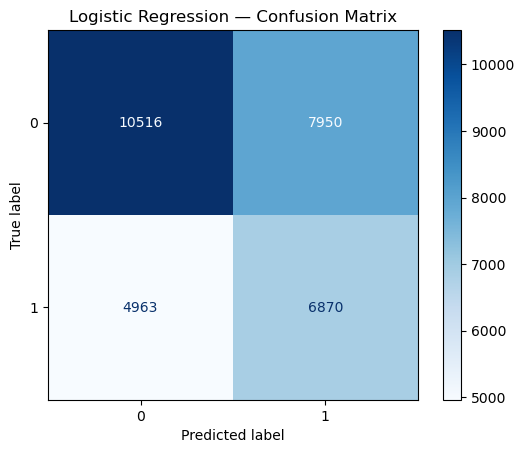

In [108]:
ConfusionMatrixDisplay.from_predictions(y_test, logreg_pred, cmap="Blues")
plt.title("Logistic Regression — Confusion Matrix")
plt.savefig("cm_logreg.png", dpi=200, bbox_inches="tight")
plt.show()

## Q2 Findings 

- On a held-out 2025-2026 test set, Logistic Regression performed best (ROC-AUC 0.61,
  F1 0.52 on poor outcomes), narrowly ahead of Random Forest (0.60) and Decision Tree (0.57).
    
- All three models showed only modest predictive power, indicating that poor inspection
  outcomes are difficult to predict from inspection history, restaurant characteristics,
  and rodent activity alone.
      
- The Decision Tree caught most poor outcomes but flagged too many restaurants; Random
  Forest favoured accuracy but missed most poor outcomes.
      
- Logistic Regression offered the best balance for identifying at-risk restaurants.

# Section 12 - Does Rodent Activity Improve Prediction?

- The main inquiry is whether local rodent activity adds useful information beyond restaurant inspection hisotry. 

- We test this directly by training the best model (Logistic Regression) on two feature sets (with and without rodent activity) and comparing test-set performance.

In [109]:
# Define the two feature sets: one excluding rodent activity, one including it

rodent_col = "rodent_activity_prev_month"
features_without = [c for c in X.columns if c != rodent_col]

# Model A: WITHOUT rodent activity

X_train_a = scaler.fit_transform(X_train[features_without])
X_test_a = scaler.transform(X_test[features_without])
model_a = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=123)
model_a.fit(X_train_a, y_train)
auc_a = roc_auc_score(y_test, model_a.predict_proba(X_test_a)[:, 1])

# Model B: WITH rodent activity (full feature set)

X_train_b = scaler.fit_transform(X_train)
X_test_b = scaler.transform(X_test)
model_b = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=123)
model_b.fit(X_train_b, y_train)
auc_b = roc_auc_score(y_test, model_b.predict_proba(X_test_b)[:, 1])

print("Model A (without rodent activity): ROC-AUC =", round(auc_a, 4))
print("Model B (with rodent activity):    ROC-AUC =", round(auc_b, 4))
print("Improvement from adding rodent activity:", round(auc_b - auc_a, 4))

Model A (without rodent activity): ROC-AUC = 0.6098
Model B (with rodent activity):    ROC-AUC = 0.61
Improvement from adding rodent activity: 0.0002


**Does rodent activity improve prediction?**
    
- Logistic Regression was trained with and without the rodent-activity feature on the
  same time-based split.
      
- Adding rodent activity changed test-set ROC-AUC from 0.6098 to 0.6100, an improvement
  of just 0.0002.
      
- This confirms the Q1 finding through a second, independent method: once inspection
  history and restaurant characteristics are accounted for, local rodent activity adds
  no meaningful predictive value.

# Section 13 - Export Outputs 

In [110]:
# add predictied risk probability for the whole dataset 

scaler_full = StandardScaler()
X_all_scaled = scaler_full.fit_transform(X)

logreg_full = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=123)
logreg_full.fit(X_all_scaled, y)

model_data["predicted_risk_probability"] = logreg_full.predict_proba(X_all_scaled)[:, 1]

print(model_data[["CAMIS", "poor_outcome", "predicted_risk_probability"]].head())

      CAMIS  poor_outcome  predicted_risk_probability
1  30075445             0                    0.463052
2  30075445             0                    0.509521
3  30075445             0                    0.482066
5  30191841             1                    0.496522
6  30191841             0                    0.438901


In [111]:
# export the dashboard dataset for Q3 


dashboard_full = inspections.copy()

# Map the predicted probabilities from model_data back onto the full set by index

preds = model_data[["CAMIS", "INSPECTION DATE", "predicted_risk_probability"]]
dashboard_full = dashboard_full.merge(preds, on=["CAMIS", "INSPECTION DATE"], how="left")

# Select the columns the Q3 dashboard needs

dashboard_cols = [
    "CAMIS", "DBA", "BORO", "ZIPCODE", "CUISINE_CLEAN",
    "INSPECTION DATE", "year", "month", "season",
    "score", "poor_outcome",
    "rodent_activity_prev_month", "predicted_risk_probability",
    "latitude", "longitude"
]
dashboard_full = dashboard_full[dashboard_cols]

dashboard_full.to_csv("dashboard_dataset_full.csv", index=False)

print("Full dashboard dataset exported:", dashboard_full.shape)
print("Rows with a predicted risk score:",
      dashboard_full["predicted_risk_probability"].notna().sum())
print("Rows without (first inspections):",
      dashboard_full["predicted_risk_probability"].isna().sum())

Full dashboard dataset exported: (82601, 15)
Rows with a predicted risk score: 55278
Rows without (first inspections): 27323


# Section 14 - Final Summary, Limitations, and Strategic Implications 

## Summary of Findings

- Q1 (Statistical Inference): Logistic regression identified cuisine type and inspection
history as the main significant predictors of a poor inspection outcome. Indian, Thai,
and Asian/Asian Fusion restaurants had the highest odds, while Donuts, Hamburgers, and
Coffee/Tea had the lowest. A higher previous score and a longer gap since the last
inspection also raised the odds. Local rodent activity was not a statistically
significant predictor (p ≈ 0.09).

- Q2 (Machine Learning): Three models were compared on a time-based test set (2025-2026).
Logistic Regression performed best (ROC-AUC 0.61), narrowly ahead of Random Forest and
Decision Tree. All models showed only modest predictive power, indicating that
individual inspection outcomes are difficult to predict from the available features.

- Main Inquiry: Both methods agreed. Adding rodent activity to the model improved ROC-AUC
by only 0.0002, confirming the Q1 result that local rodent activity adds no meaningful
predictive value once inspection history and restaurant characteristics are accounted
for.

## Limitations

- The models identify associations, not causes. The cuisine effects in particular
  likely reflect differences in operational complexity and the number of inspectable
  food-handling steps, rather than differences in hygiene standards, and should not be
  read as judgements about specific communities.
  
- Rodent inspection records reflect where inspections occurred, which may differ from
  true rodent populations.

  
- The ZIP-and-month merge captures area-level rodent activity, not street-level
  proximity, so a finer spatial link might reveal relationships this analysis cannot.

  
- Predictive power was modest overall, reflecting genuine inspection-to-inspection
  variability rather than a modelling fault.

## Strategic Implications

- Health authorities can prioritise inspections using restaurant inspection history and
  cuisine type, which carry the strongest signal, rather than relying on local rodent
  activity data for this purpose.
  
- The finding that rodent activity adds little predictive value helps avoid misdirecting
  limited inspection resources toward an area-level signal that does not improve
  restaurant-level risk prediction.

  
- Restaurant operators with a weaker inspection history represent the clearest target
  for proactive support and re-inspection.